### 1. Scenario & Specifications
I choose scenario A.  
  
Specifications:  
Rise time requirement - When a step input is applied, the 10% to 90% rise time must satisfy $T_r \le 12~\text{ms}$.  
Noise attenuation requirement - For a 500 Hz sinusoidal noise signal, the amplitude ratio must satisfy $A(500) \le 0.30$  
  
Constraints:  
Resistance - 1 k$\Omega$ to 100 k$\Omega$  
or  
Capacitance - 0.01 $\mu F$ to 10 $\mu F$  

Best Design Criteria:  
Maximize margins, so the greatest sum of the rise-time and noise attenuation margins would be selected.



### 2. Model & Methods  

RC Differential Equation:  
$
\frac{dV_c}{dt} = \frac{V_{\text{in}}(t) - V_c}{RC}
$  

Sinusoidal Input:  
$
V_{\text{in}}(t) = A_0 \sin(2\pi f t)
$  

Step Input:  
$
V_{\text{in}}(t) = V_0*u(t)  
$  

To find rise time, apply a step input to the circuit, then measure the time it takes for the output voltage to go from 10% to 90% of its final value. By solving the RC ODE, rise time can be estimated as $2.2\tau$.

To find the amplitude ratio, you divide the final amplitude by the inital amplitude.


### 3. Design Candidates

For R: 1, 20, 50, and 100 k$\Omega$  
For C: 0.01, 0.1, 1, and 10 $\mu F$  

I chose these 16 values using a grid-based approach to evenly cover the ranges given.

### 4. Simulation & Results

Best Design:
R = 1.0 kΩ
C = 0.01 µF
Rise Time = 0.02197197197197197 ms
Amplitude Ratio at 500 Hz = 0.015366482619620057


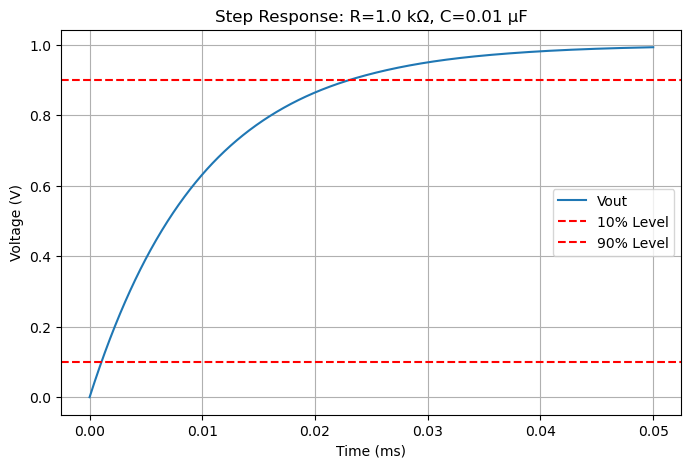

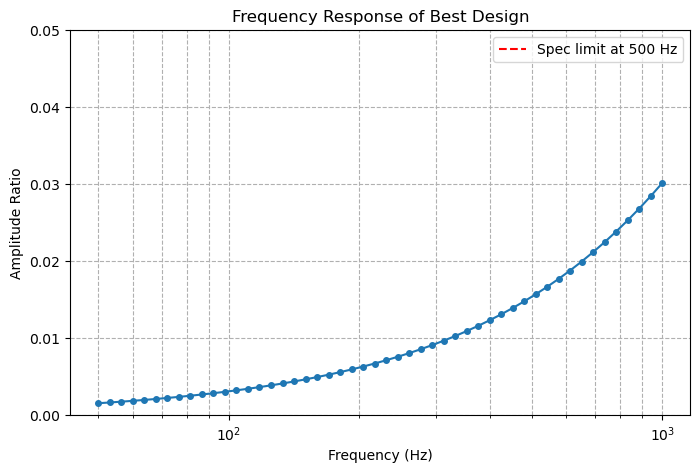

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def rc_filter(t, Vout, Vin_func, R, C):
    Vin = Vin_func(t)
    dVout_dt = (Vin - Vout[0]) / (R*C)  # Fixed: divide by RC
    return [dVout_dt]

def step_input(t, V0=1.0):
    return V0 if t >= 0 else 0

def sinusoid_input(t, f=500, A=1.0):
    return A*np.sin(2*np.pi*f*t)

def compute_rise_time(R, C, V0=1.0):
    tau = R*C
    t_end = 5*tau
    t_eval = np.linspace(0, t_end, 1000)
    
    sol = solve_ivp(rc_filter, [0, t_end], [0], t_eval=t_eval, args=(lambda t: step_input(t, V0), R, C))
    Vout = sol.y[0]
    
    t10_indices = np.where(Vout >= 0.1*V0)[0] #finds instances of crossing 10%
    t10 = sol.t[t10_indices[0]] if len(t10_indices) > 0 else np.nan #finds first instance or gives n/a
    
    t90_indices = np.where(Vout >= 0.9*V0)[0] #same but for 90
    t90 = sol.t[t90_indices[0]] if len(t90_indices) > 0 else np.nan
    
    Tr = t90 - t10 #subtracts for rise time
    return Tr, sol.t, Vout

def compute_amplitude_ratio(R, C, f=500, A=1.0):
    
    tau = R*C
    t_end = 5*tau
    t_eval = np.linspace(0, t_end, 1000)
    
    sol = solve_ivp(rc_filter, [0, t_end], [0], t_eval=t_eval, args=(lambda t: sinusoid_input(t, f, A), R, C))
    Vout = sol.y[0]
    
    steady_samples = int(0.2 * len(Vout)) #last 20% of samples
    finalAmp = (np.max(Vout[-steady_samples:]) - np.min(Vout[-steady_samples:])) / 2  # Fixed variable name
    
    return finalAmp / A

R_values = [1e3, 20e3, 50e3, 100e3]       # Resistance in ohms
C_values = [0.01e-6, 0.1e-6, 1e-6, 10e-6] # Capacitance in farads

results = []  # list to store results

for R in R_values:
    for C in C_values:
        # Compute rise time
        Tr, _, _ = compute_rise_time(R, C)
        
        # Compute amplitude ratio at 500 Hz
        A500 = compute_amplitude_ratio(R, C, f=500)
        
        # Store results (convert Tr to ms)
        results.append({'R': R, 'C': C, 'Tr': Tr*1000, 'A500': A500})

filtered = [r for r in results if r['Tr'] <= 12 and r['A500'] <= 0.3]

for r in filtered:
    r['margin'] = (12 - r['Tr']) + (0.3 - r['A500'])
best_design = max(filtered, key=lambda x: x['margin'])

# Print best design
print("Best Design:")
print("R =", best_design['R']/1e3, "kΩ")    
print("C =", best_design['C']*1e6, "µF")        
print("Rise Time =", best_design['Tr'], "ms")
print("Amplitude Ratio at 500 Hz =", best_design['A500'])

Tr, t, Vout = compute_rise_time(best_design['R'], best_design['C'])
plt.figure(figsize=(8,5))
plt.plot(t*1000, Vout, label='Vout')  # convert time to ms
plt.axhline(0.1, color='r', linestyle='--', label='10% Level')
plt.axhline(0.9, color='r', linestyle='--', label='90% Level')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title(f"Step Response: R={best_design['R']/1e3:.1f} kΩ, C={best_design['C']*1e6:.2f} µF")
plt.legend()
plt.grid(True)
plt.show()


frequencies = np.logspace(np.log10(50), np.log10(1000), 50) #uses 50 points
A_vals = [compute_amplitude_ratio(best_design['R'], best_design['C'], f=f) for f in frequencies]
plt.figure(figsize=(8,5))
plt.semilogx(frequencies, A_vals, marker='o', markersize=4)
plt.axhline(0.3, color='r', linestyle='--', label='Spec limit at 500 Hz')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude Ratio")
plt.title("Frequency Response of Best Design")
plt.ylim(0, 0.05)
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()



### 7. Reflection  
The hardest part of my design was figuring out how to quantify the rise-time and maximize margins. A faster rise-time usually means more noise and vice versa, so the optimized values were in the middle. If I had another week, I'd likely experiment with greater datasets.